# <B><I><U>student_mental_health_burnout_1M </U>----</B></I>

In [ ]:
# FOR PATH RECOGNISION ----

from pathlib import Path

print("Current Folder:")
print(Path.cwd())

print("\nParent:")
print(Path.cwd().parent)

Current Folder:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\student_mental_health_burnout

Parent:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks


In [1]:
# IGNORE WARNING --

import warnings

warnings.filterwarnings("ignore")

In [3]:
# IMPORTING ALL THE NECESSARY LIBRARIES --

# Data Handling

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

# Train Test Split

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# Models

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Saving

import joblib

# Display

pd.set_option(
    "display.max_columns",
    None
)

sns.set_style("whitegrid")

print("all the necessary libraries are imported sucessfully:")
print("🎉🎉🎉🎉")

all the necessary libraries are imported sucessfully:
🎉🎉🎉🎉


In [4]:
# LOADING DATASET --

from pathlib import Path

BASE_DIR = Path.cwd().parents[1]

df = pd.read_csv(
    BASE_DIR /
    "datasets" /
    "student_mental_health_burnout_1M.csv"
)

df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [5]:
# SHAPE OF DATASET --

print(df.shape)

(1000000, 20)


In [6]:
# INFORMATION --

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [7]:
# STATISTICAL SUMMARY --

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,22.996456,3.742579,17.000000,20.000000,23.000000,26.000000,29.000000
academic_year,1000000.0,2.500782,1.117749,1.000000,2.000000,3.000000,4.000000,4.000000
study_hours_per_day,1000000.0,5.001727,1.989340,0.000000,3.650644,4.998222,6.345532,14.000000
exam_pressure,1000000.0,5.998810,1.548268,1.000000,4.944647,5.998906,7.051914,10.000000
academic_performance,1000000.0,70.999135,5.660073,42.365714,67.180912,70.999914,74.820937,97.246309
stress_level,1000000.0,4.246462,1.678998,0.000000,3.102593,4.244029,5.385464,10.000000
anxiety_score,1000000.0,2.986413,1.509844,0.000000,1.923747,2.969514,4.014996,10.000000
depression_score,1000000.0,1.274728,1.221273,0.000000,0.005198,1.047839,2.086397,8.530800
sleep_hours,1000000.0,6.501713,1.472972,3.000000,5.491047,6.501938,7.514642,10.000000
physical_activity,1000000.0,3.011153,1.463679,0.000000,1.990596,3.000619,4.011208,7.000000


In [9]:
# NULL VALUES --

if df.isnull().values.any():
    print("a")
else:
    print("NO NULL VALUES:✅✅")


NO NULL VALUES:✅✅


In [10]:
# DUPLICATES --

print(
    "Duplicates:",
    df.duplicated().sum()
)

Duplicates: 0


# <B><I><U>CORRELATION</U> ----</B></I>

In [11]:
# TARGET --

df["burnout_score"].describe()

count    1000000.000000
mean           1.784073
std            1.664035
min            0.000000
25%            0.124810
50%            1.496505
75%            2.889473
max           10.000000
Name: burnout_score, dtype: float64

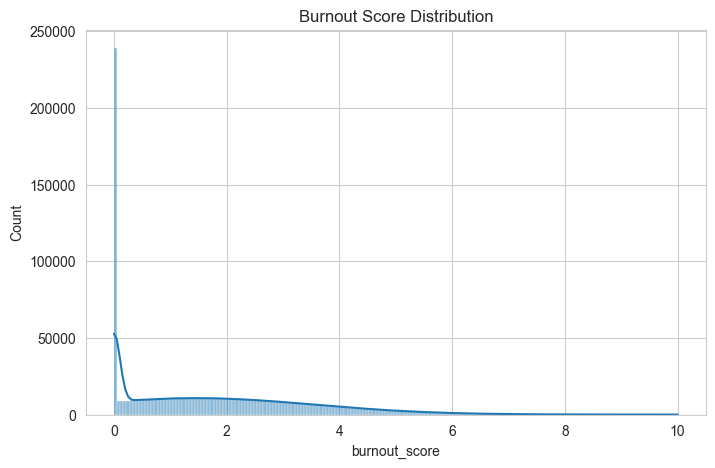

In [12]:
# DISTRIBUTION OF TARGET --

plt.figure(figsize=(8,5))

sns.histplot(
    df["burnout_score"],
    kde=True
)

plt.title(
    "Burnout Score Distribution"
)

plt.show()

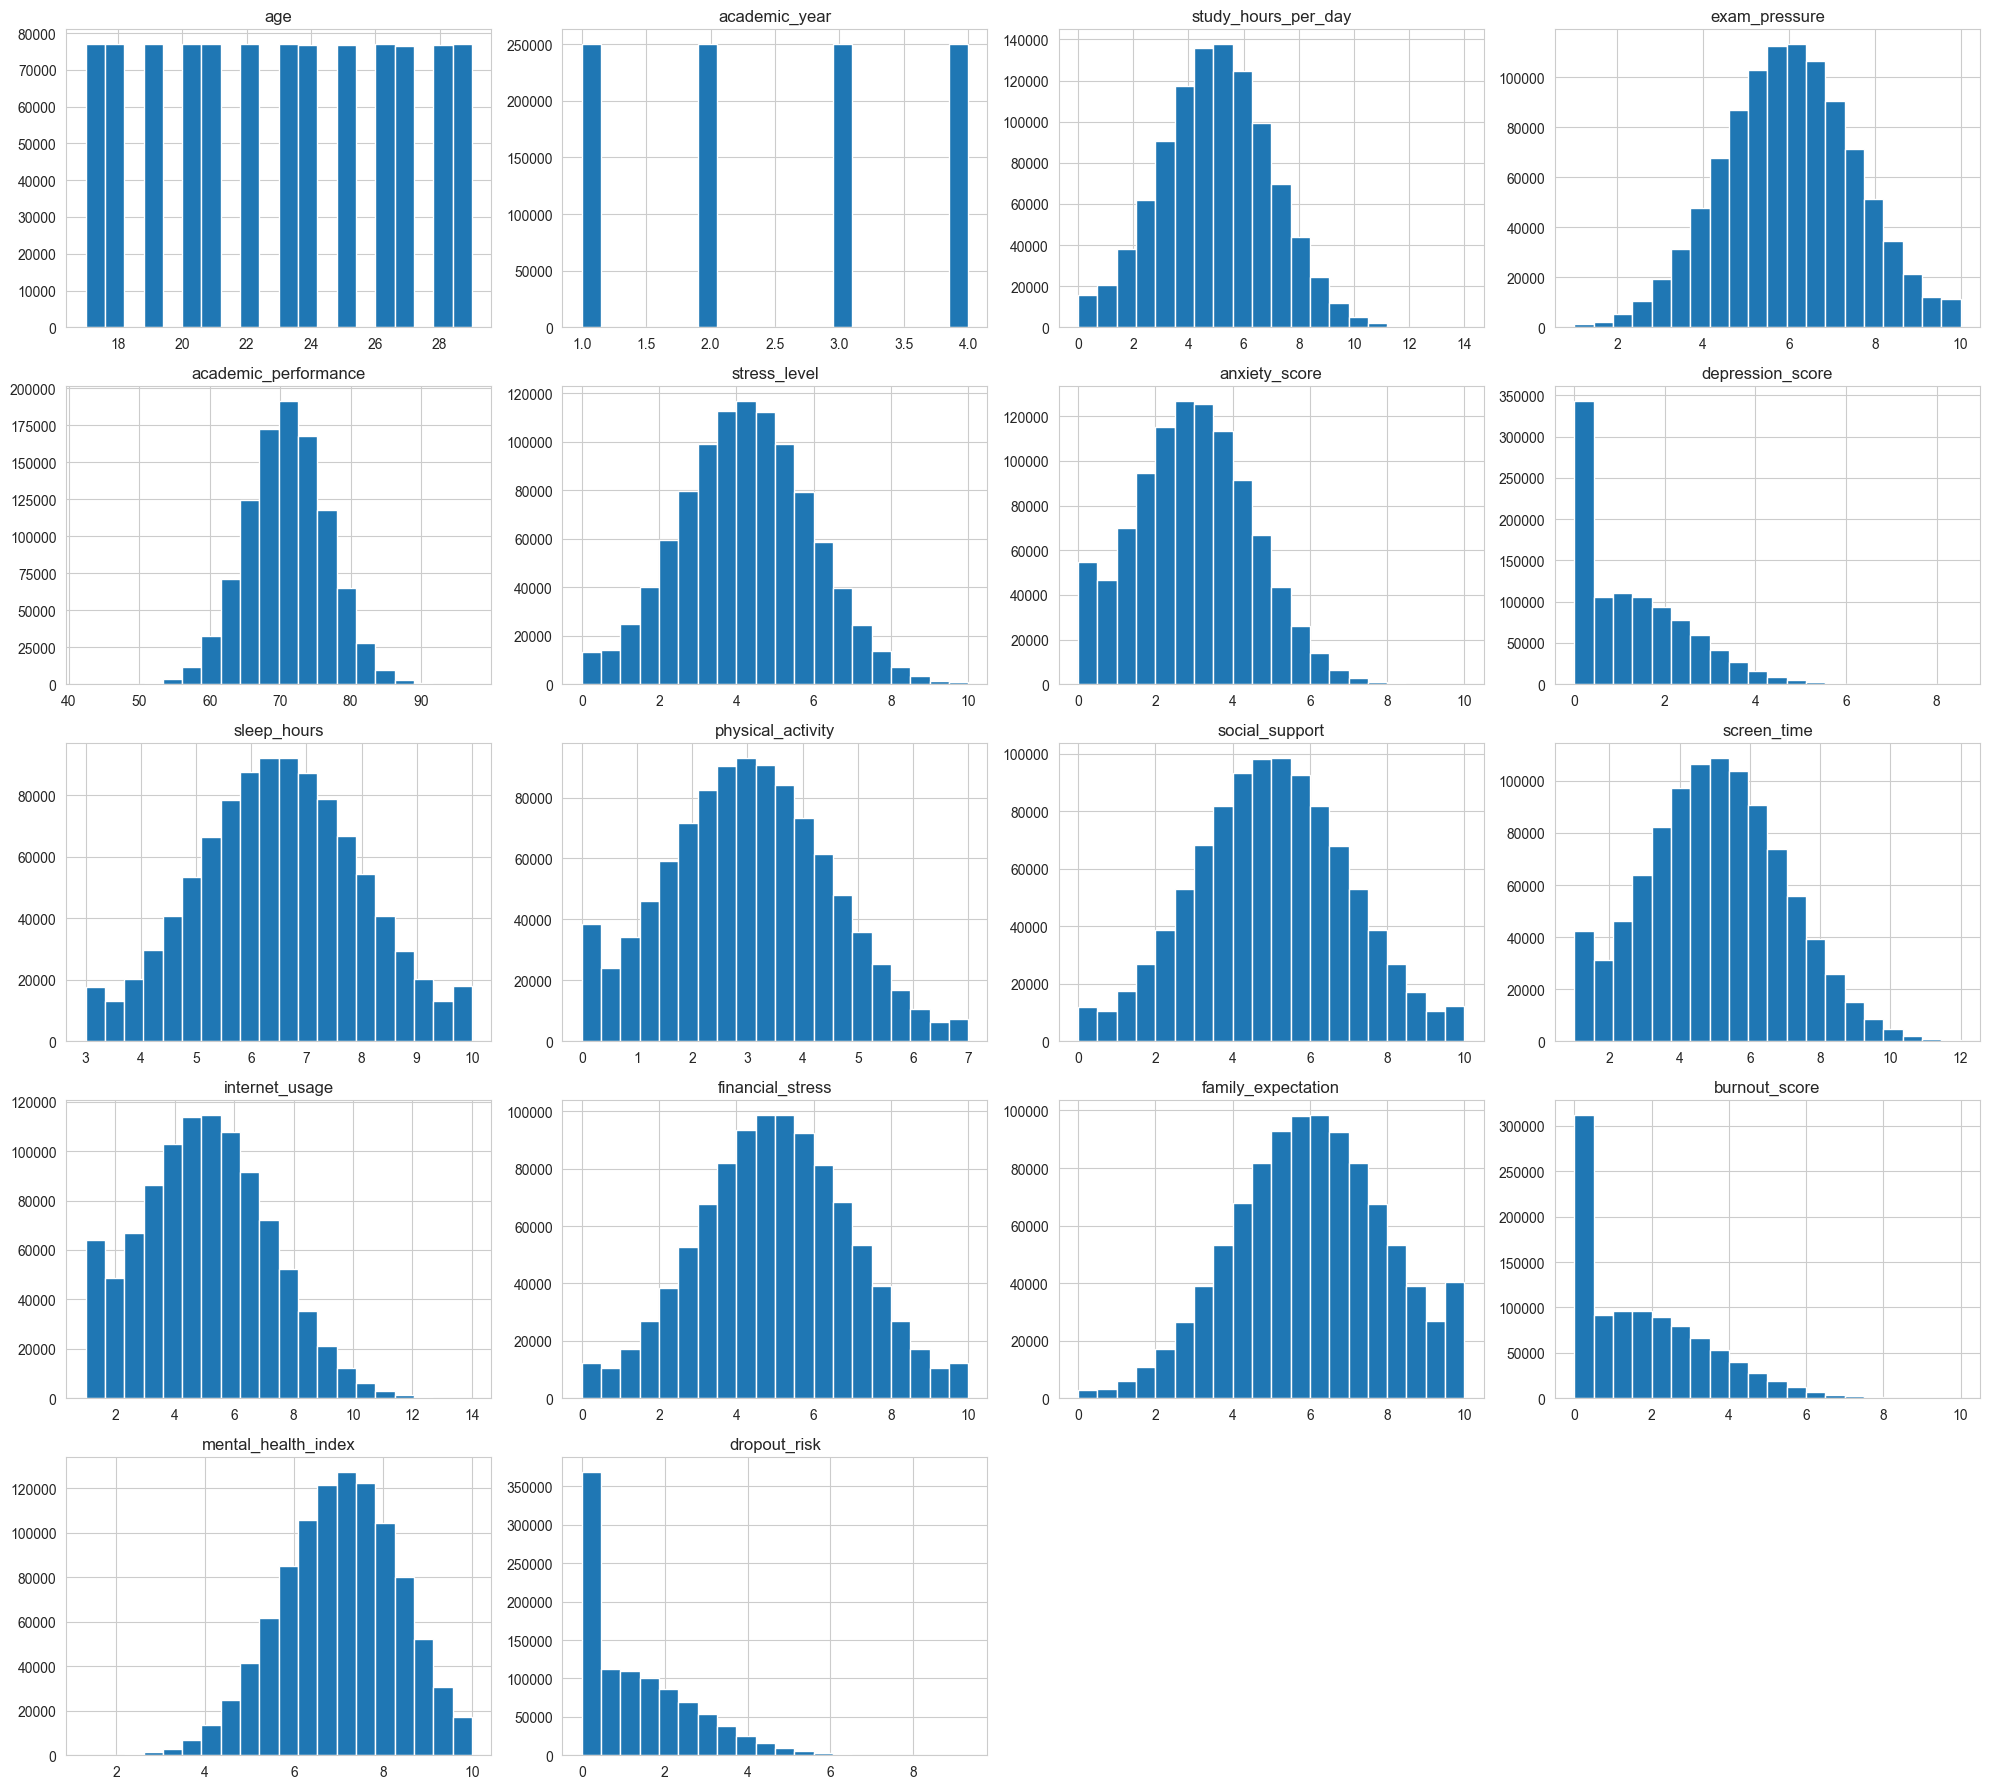

In [13]:
# DISTRIBUTION OF FEATURES --

df.hist(
    figsize=(20,18),
    bins=20
)

plt.tight_layout()

plt.show()

In [20]:
# # CORRELATION MATRIX --

# corr_matrix = df.corr()

# corr_matrix

In [21]:
# target --

y = df["burnout_score"]

In [22]:
# DROPPING COLUMNS --

X = df.drop(
    columns=[
        "burnout_score",
        "risk_level",
        "dropout_risk"
    ]
)

# <B><U><I>FEATURE ENGINNERING </U>----</B></I>

In [23]:
df_fe = df.copy()

df_fe.shape

(1000000, 20)

In [24]:
# MENTAL STRESS SCORE --

df_fe["mental_stress_score"] = (
    df_fe[
        [
            "stress_level",
            "anxiety_score",
            "depression_score"
        ]
    ]
    .mean(axis=1)
)

In [25]:
# LIFE STYLE SCORE --

df_fe["lifestyle_score"] = (
    df_fe[
        [
            "sleep_hours",
            "physical_activity",
            "social_support"
        ]
    ]
    .mean(axis=1)
)

In [26]:
# DIGITAL OVERLOAD --

df_fe["digital_overload"] = (
    df_fe[
        [
            "screen_time",
            "internet_usage"
        ]
    ]
    .mean(axis=1)
)

In [27]:
# ACADEMIC LOAD --

df_fe["academic_load"] = (
    df_fe[
        [
            "study_hours_per_day",
            "exam_pressure"
        ]
    ]
    .mean(axis=1)
)

In [28]:
# EXTERNAL STRESS --

df_fe["external_stress"] = (
    df_fe[
        [
            "financial_stress",
            "family_expectation"
        ]
    ]
    .mean(axis=1)
)

In [29]:
# WORK LIFE INBALANCE --

df_fe["work_life_imbalance"] = (
    df_fe["study_hours_per_day"]
    /
    (
        df_fe["sleep_hours"]
        + 1
    )
)

In [30]:
# SLEEP DEFICIT --

df_fe["sleep_deficit"] = (
    8 - df_fe["sleep_hours"]
)

df_fe["sleep_deficit"] = (
    df_fe["sleep_deficit"]
    .clip(lower=0)
)

In [31]:
# NORMALISE BURNOUT --

df_fe["normalized_burnout"] = (
    df_fe["burnout_score"]
    /
    10
)

# <B><U><I>ENCODING</U> ----</B></I>

In [32]:
# ENCODE GENDER --

df_fe["gender"] = (
    df_fe["gender"]
    .map({
        "Male": 1,
        "Female": 0
    })
)

In [33]:
# RISK LEVEL --

df_fe["risk_level"] = (
    df_fe["risk_level"]
    .map({
        "Low": 0,
        "Medium": 1,
        "High": 2
    })
)

In [34]:
# SAVING ENGGINNEERED DATASET --

PREPROCESS_DIR = (
    Path.cwd().parent /
    "preprocessED"
)

PREPROCESS_DIR.mkdir(
    exist_ok=True
)

df_fe.to_csv(
    PREPROCESS_DIR /
    "burnout_feature_engineered.csv",
    index=False
)

In [38]:
df_fe.shape

df_fe.head()

df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 28 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                959713 non-null   float64
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [40]:
df_fe["gender"].value_counts(dropna=False)

df_fe["gender"] = (
    df_fe["gender"]
    .fillna(
        df_fe["gender"].mode()[0]
    )
)

In [41]:
drop_cols = [
    "risk_level",
    "dropout_risk",
    "normalized_burnout"
]

df_fe = df_fe.drop(
    columns=drop_cols
)

# <B><I><U>EDA</U> ----</B></I>

In [42]:
# DATASET SHAPE --

print("Rows :", df_fe.shape[0])
print("Columns :", df_fe.shape[1])

Rows : 1000000
Columns : 25


In [43]:
# MISSING VALUES --

missing = (
    df_fe.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing[missing > 0]

Series([], dtype: int64)

# <B><U><I>CORRELATION </U> ----</B></I>

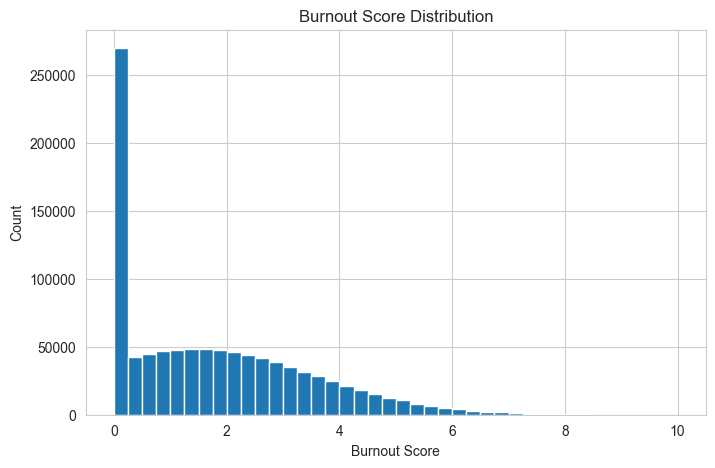

In [44]:
# TARGET DISTRIBUTION --

plt.figure(figsize=(8,5))

plt.hist(
    df_fe["burnout_score"],
    bins=40
)

plt.title("Burnout Score Distribution")

plt.xlabel("Burnout Score")

plt.ylabel("Count")

plt.show()

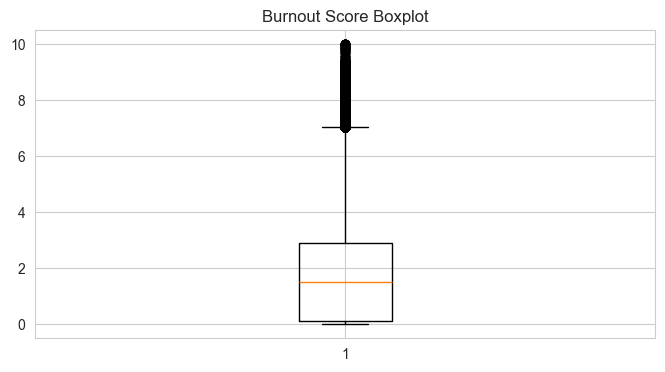

In [45]:
plt.figure(figsize=(8,4))

plt.boxplot(
    df_fe["burnout_score"]
)

plt.title("Burnout Score Boxplot")

plt.show()

In [46]:
# CORRE. WITH TARGET --

corr_target = (
    df_fe
    .corr(numeric_only=True)
    ["burnout_score"]
    .sort_values(
        ascending=False
    )
)

corr_target

burnout_score           1.000000
mental_stress_score     0.796146
stress_level            0.753111
anxiety_score           0.668450
depression_score        0.642612
work_life_imbalance     0.470421
exam_pressure           0.434376
academic_load           0.402444
sleep_deficit           0.369751
external_stress         0.363539
study_hours_per_day     0.335132
financial_stress        0.295702
family_expectation      0.217843
academic_performance    0.057089
academic_year           0.000555
gender                 -0.000138
age                    -0.001016
internet_usage         -0.001151
screen_time            -0.001215
digital_overload       -0.001215
physical_activity      -0.110074
social_support         -0.229811
sleep_hours            -0.371386
lifestyle_score        -0.405226
mental_health_index    -0.796527
Name: burnout_score, dtype: float64

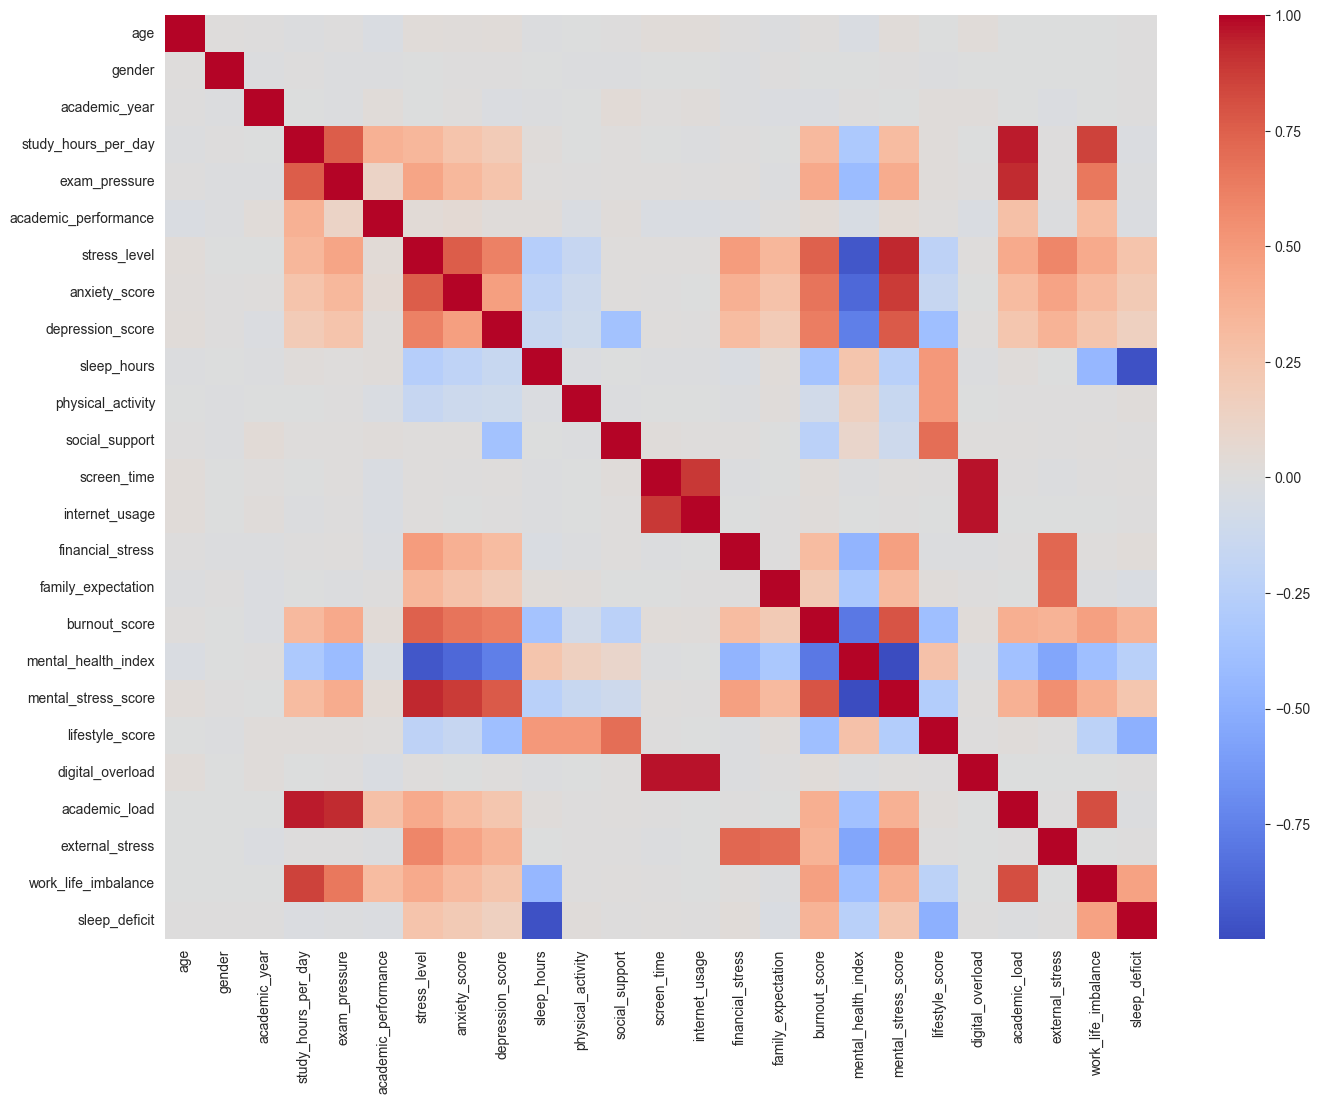

In [47]:
# HEATMAP --

sample_df = df_fe.sample(
    5000,
    random_state=42
)

plt.figure(
    figsize=(16,12)
)

sns.heatmap(
    sample_df.corr(
        numeric_only=True
    ),
    cmap="coolwarm"
)

plt.show()

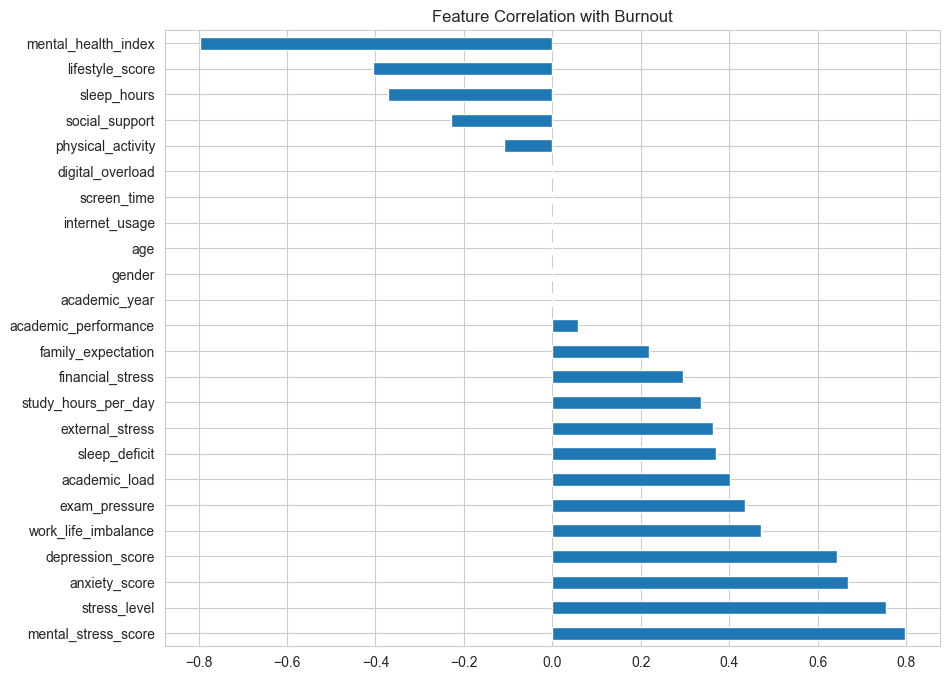

In [48]:
# FEATURE CORR. --

plt.figure(
    figsize=(10,8)
)

corr_target.drop(
    "burnout_score"
).plot(
    kind="barh"
)

plt.title(
    "Feature Correlation with Burnout"
)

plt.show()

In [49]:
# CHECK MULTTICOLINEARITY --

corr_matrix = (
    df_fe
    .corr(
        numeric_only=True
    )
    .abs()
)

high_corr = []

for col in corr_matrix.columns:

    for row in corr_matrix.index:

        if (
            row != col
            and
            corr_matrix.loc[row,col] > 0.90
        ):

            high_corr.append(
                (
                    row,
                    col,
                    corr_matrix.loc[row,col]
                )
            )

high_corr[:20]

[('academic_load', 'study_hours_per_day', np.float64(0.954240306892555)),
 ('academic_load', 'exam_pressure', np.float64(0.9232366337247615)),
 ('mental_health_index', 'stress_level', np.float64(0.9493930130680922)),
 ('mental_stress_score', 'stress_level', np.float64(0.9340265596031735)),
 ('sleep_deficit', 'sleep_hours', np.float64(0.9748532216624153)),
 ('digital_overload', 'screen_time', np.float64(0.9696722341111963)),
 ('digital_overload', 'internet_usage', np.float64(0.9750310462536128)),
 ('stress_level', 'mental_health_index', np.float64(0.9493930130680922)),
 ('mental_stress_score',
  'mental_health_index',
  np.float64(0.9989525723509378)),
 ('stress_level', 'mental_stress_score', np.float64(0.9340265596031735)),
 ('mental_health_index',
  'mental_stress_score',
  np.float64(0.9989525723509378)),
 ('screen_time', 'digital_overload', np.float64(0.9696722341111963)),
 ('internet_usage', 'digital_overload', np.float64(0.9750310462536128)),
 ('study_hours_per_day', 'academic_loa

In [50]:
corr_target

burnout_score           1.000000
mental_stress_score     0.796146
stress_level            0.753111
anxiety_score           0.668450
depression_score        0.642612
work_life_imbalance     0.470421
exam_pressure           0.434376
academic_load           0.402444
sleep_deficit           0.369751
external_stress         0.363539
study_hours_per_day     0.335132
financial_stress        0.295702
family_expectation      0.217843
academic_performance    0.057089
academic_year           0.000555
gender                 -0.000138
age                    -0.001016
internet_usage         -0.001151
screen_time            -0.001215
digital_overload       -0.001215
physical_activity      -0.110074
social_support         -0.229811
sleep_hours            -0.371386
lifestyle_score        -0.405226
mental_health_index    -0.796527
Name: burnout_score, dtype: float64

In [51]:
drop_cols = [
    "age",
    "gender",
    "academic_year",
    "internet_usage",
    "screen_time",
    "digital_overload"
]

df_model = df_fe.drop(
    columns=drop_cols
)